In [2]:
pip install timm pillow

   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.6 MB 6.3 MB/s eta 0:00:01
   ------------------------------------ --- 2.4/2.6 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 2.6/2.6 MB 5.3 MB/s  0:00:00
   ---------------------------------------- 0.0/793.2 kB ? eta -:--:--
   ---------------------------------------- 793.2/793.2 kB 5.6 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------------ --------------------------- 1.3/4.0 MB 6.7 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.0 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 6.9 MB/s  0:00:00
   ---------------------------------------- 0.0/122.0 MB ? eta -:--:--
    --------------------------------------- 1.6/122.0 MB 8.4 MB/s eta 0:00:15
    --------------------------------------- 2.9/122.0 MB 7.6 MB/s eta 0:00:16
   - --------------------------------

In [3]:
import os
import json
import pickle
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

import timm

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

BASE_PATH = Path(r"E:\Thesis")
HAM_PATH = BASE_PATH / "HAM10000"
PAD_PATH = BASE_PATH / "PAD-UFES-20"

HAM_IMAGE_DIR = HAM_PATH / "images"
PAD_IMAGE_DIR = PAD_PATH / "images"

OUT_DIR = BASE_PATH / "outputs" / "swin_tiny_baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 2   # GTX 1650-এর জন্য safe; ঠিক থাকলে 4 try করতে পারো
EPOCHS = 20
NUM_CLASSES = 4

CLASS_NAMES = ["ACK", "BCC", "MEL", "NEV"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Output folder:", OUT_DIR)

Device: cuda
Output folder: E:\Thesis\outputs\swin_tiny_baseline


In [6]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce GTX 1650


In [7]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.7.1+cu118
True
NVIDIA GeForce GTX 1650


In [8]:
ham = pd.read_csv(HAM_PATH / "HAM10000_metadata.csv")
pad = pd.read_csv(PAD_PATH / "metadata.csv")

print("HAM shape:", ham.shape)
print("PAD shape:", pad.shape)

HAM shape: (10015, 8)
PAD shape: (2298, 26)


In [9]:
HAM_CLASSES = ["akiec", "bcc", "mel", "nv"]
PAD_CLASSES = ["ACK", "BCC", "MEL", "NEV"]

ham_4 = ham[ham["dx"].isin(HAM_CLASSES)].copy()
ham_4["label"] = ham_4["dx"].map({
    "akiec": "ACK",
    "bcc": "BCC",
    "mel": "MEL",
    "nv": "NEV"
})

pad_4 = pad[pad["diagnostic"].isin(PAD_CLASSES)].copy()
pad_4["label"] = pad_4["diagnostic"]

print("HAM class counts:")
print(ham_4["label"].value_counts())
print("\nPAD class counts:")
print(pad_4["label"].value_counts())

HAM class counts:
label
NEV    6705
MEL    1113
BCC     514
ACK     327
Name: count, dtype: int64

PAD class counts:
label
BCC    845
ACK    730
NEV    244
MEL     52
Name: count, dtype: int64


In [10]:
# HAM: image_id সাধারণত .jpg
ham_4["image_path"] = ham_4["image_id"].apply(lambda x: str(HAM_IMAGE_DIR / f"{x}.jpg"))

# PAD: img_id এর মধ্যে .png already আছে
pad_4["image_path"] = pad_4["img_id"].apply(lambda x: str(PAD_IMAGE_DIR / x))

ham_4["exists"] = ham_4["image_path"].apply(os.path.exists)
pad_4["exists"] = pad_4["image_path"].apply(os.path.exists)

print("HAM exists:")
print(ham_4["exists"].value_counts())

print("\nPAD exists:")
print(pad_4["exists"].value_counts())

HAM exists:
exists
True    8659
Name: count, dtype: int64

PAD exists:
exists
True    1871
Name: count, dtype: int64


In [11]:
print("HAM labels:", sorted(ham_4["label"].unique()))
print("PAD labels:", sorted(pad_4["label"].unique()))
print("Same classes:", set(ham_4["label"].unique()) == set(pad_4["label"].unique()))

HAM labels: ['ACK', 'BCC', 'MEL', 'NEV']
PAD labels: ['ACK', 'BCC', 'MEL', 'NEV']
Same classes: True


In [12]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, val_idx = next(gss.split(ham_4, groups=ham_4["lesion_id"]))

train_df = ham_4.iloc[train_idx].copy()
val_df = ham_4.iloc[val_idx].copy()

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("PAD test samples:", len(pad_4))

Training samples: 6932
Validation samples: 1727
PAD test samples: 1871


In [13]:
train_df.to_csv(OUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUT_DIR / "val_split.csv", index=False)
pad_4.to_csv(OUT_DIR / "pad_test_split.csv", index=False)

In [14]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_to_idx=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = row["label"]

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        y = self.label_to_idx[label]
        return image, torch.tensor(y, dtype=torch.long)

In [15]:
# ImageNet normalization for Swin-T pretrained weights
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

pad_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [16]:
label_to_idx = {
    "ACK": 0,
    "BCC": 1,
    "MEL": 2,
    "NEV": 3
}

idx_to_label = {v: k for k, v in label_to_idx.items()}
print(label_to_idx)

{'ACK': 0, 'BCC': 1, 'MEL': 2, 'NEV': 3}


In [17]:
train_dataset = SkinLesionDataset(train_df, transform=train_transform, label_to_idx=label_to_idx)
val_dataset = SkinLesionDataset(val_df, transform=val_transform, label_to_idx=label_to_idx)
pad_dataset = SkinLesionDataset(pad_4, transform=pad_transform, label_to_idx=label_to_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
pad_loader = DataLoader(pad_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("PAD batches:", len(pad_loader))

Train batches: 3466
Val batches: 864
PAD batches: 936


In [18]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)
print(model)

model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

c:\Users\parth\miniconda3\envs\tf\lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\parth\.cache\huggingface\hub\models--timm--swin_tiny_patch4_window7_224.ms_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [20]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

C:\Users\parth\AppData\Local\Temp\ipykernel_8296\4137987549.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [21]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_probs = []
    all_preds = []
    all_true = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_true.append(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    all_probs = np.concatenate(all_probs, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    all_true = np.concatenate(all_true, axis=0)

    return epoch_loss, epoch_acc, all_probs, all_preds, all_true

In [22]:
best_val_acc = -1.0
history = []

best_path = OUT_DIR / "best_swin_tiny.pth"
last_path = OUT_DIR / "last_swin_tiny.pth"
history_csv = OUT_DIR / "history.csv"
history_json = OUT_DIR / "history.json"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device
    )

    val_loss, val_acc, val_probs, val_preds, val_true = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]["lr"]

    epoch_log = {
        "epoch": epoch + 1,
        "train_loss": float(train_loss),
        "train_acc": float(train_acc),
        "val_loss": float(val_loss),
        "val_acc": float(val_acc),
        "lr": float(current_lr)
    }
    history.append(epoch_log)

    # Save history after every epoch
    pd.DataFrame(history).to_csv(history_csv, index=False)
    with open(history_json, "w") as f:
        json.dump(history, f, indent=2)

    # Save best checkpoint first
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "history": history
        }, best_path)
        print(f"Saved best model at epoch {epoch+1} with val_acc={val_acc:.4f}")

    # Save last checkpoint every epoch
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history
    }, last_path)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"lr={current_lr:.2e}"
    )

print("Training finished.")
print("Best val accuracy:", best_val_acc)

C:\Users\parth\AppData\Local\Temp\ipykernel_8296\4276655839.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
C:\Users\parth\AppData\Local\Temp\ipykernel_8296\4276655839.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Saved best model at epoch 1 with val_acc=0.8043
Epoch 01/20 | train_loss=0.5736 train_acc=0.7817 | val_loss=0.5782 val_acc=0.8043 | lr=1.00e-04
Saved best model at epoch 2 with val_acc=0.8054
Epoch 02/20 | train_loss=0.5233 train_acc=0.7960 | val_loss=0.5188 val_acc=0.8054 | lr=1.00e-04
Saved best model at epoch 3 with val_acc=0.8373
Epoch 03/20 | train_loss=0.4928 train_acc=0.8005 | val_loss=0.4426 val_acc=0.8373 | lr=1.00e-04
Epoch 04/20 | train_loss=0.4569 train_acc=0.8120 | val_loss=0.4512 val_acc=0.8222 | lr=1.00e-04
Epoch 05/20 | train_loss=0.4317 train_acc=0.8267 | val_loss=0.4224 val_acc=0.8269 | lr=1.00e-04
Epoch 06/20 | train_loss=0.4082 train_acc=0.8364 | val_loss=0.4593 val_acc=0.8338 | lr=5.00e-05
Saved best model at epoch 7 with val_acc=0.8784
Epoch 07/20 | train_loss=0.3316 train_acc=0.8707 | val_loss=0.3308 val_acc=0.8784 | lr=5.00e-05
Epoch 08/20 | train_loss=0.2785 train_acc=0.8912 | val_loss=0.3545 val_acc=0.8703 | lr=5.00e-05
Epoch 09/20 | train_loss=0.2374 train_ac

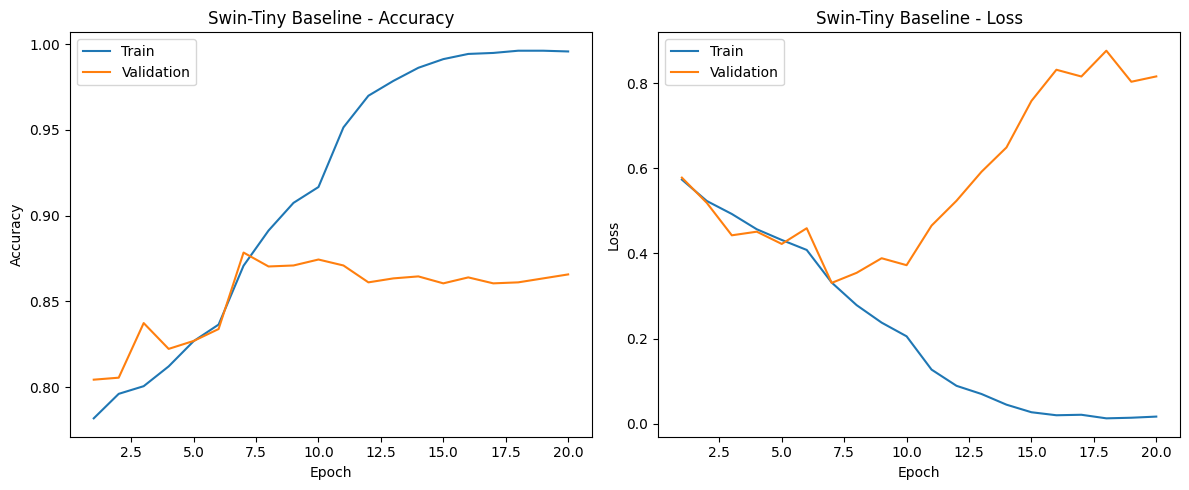

In [23]:
hist_df = pd.DataFrame(history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_df["epoch"], hist_df["train_acc"], label="Train")
plt.plot(hist_df["epoch"], hist_df["val_acc"], label="Validation")
plt.title("Swin-Tiny Baseline - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="Train")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="Validation")
plt.title("Swin-Tiny Baseline - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
model.eval()

print("Best Swin-Tiny checkpoint loaded.")
print("Best val acc from checkpoint:", ckpt["best_val_acc"])

Best Swin-Tiny checkpoint loaded.
Best val acc from checkpoint: 0.878401852924146


In [25]:
pad_loss, pad_acc, pad_probs, pad_preds, pad_true = evaluate(model, pad_loader, criterion, device)

print("PAD Accuracy:", pad_acc)
print("PAD Loss:", pad_loss)

C:\Users\parth\AppData\Local\Temp\ipykernel_8296\4276655839.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


PAD Accuracy: 0.27151256012827363
PAD Loss: 2.7767946405375086


In [26]:
acc = accuracy_score(pad_true, pad_preds)
prec = precision_score(pad_true, pad_preds, average="macro", zero_division=0)
rec = recall_score(pad_true, pad_preds, average="macro", zero_division=0)
f1 = f1_score(pad_true, pad_preds, average="macro", zero_division=0)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print(
    classification_report(
        pad_true,
        pad_preds,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Accuracy : 0.27151256012827363
Precision: 0.26447194962273013
Recall   : 0.3323344278240718
F1 Score : 0.21408573116631846
              precision    recall  f1-score   support

         ACK       0.36      0.16      0.22       730
         BCC       0.47      0.19      0.27       845
         MEL       0.02      0.04      0.03        52
         NEV       0.21      0.94      0.34       244

    accuracy                           0.27      1871
   macro avg       0.26      0.33      0.21      1871
weighted avg       0.38      0.27      0.25      1871



In [27]:
pad_true_onehot = label_binarize(pad_true, classes=[0, 1, 2, 3])

auc = roc_auc_score(
    pad_true_onehot,
    pad_probs,
    average="macro",
    multi_class="ovr"
)

print("Macro AUC:", auc)

Macro AUC: 0.6252077577283899


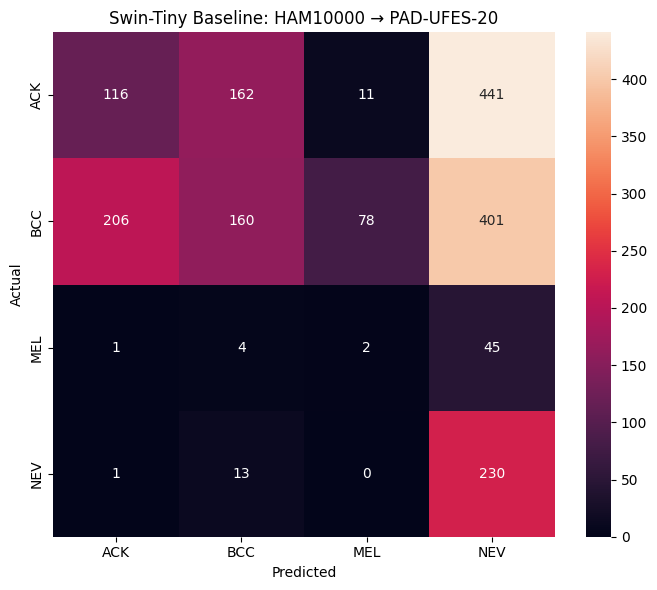

<Figure size 640x480 with 0 Axes>

In [28]:
cm = confusion_matrix(pad_true, pad_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Swin-Tiny Baseline: HAM10000 → PAD-UFES-20")
plt.tight_layout()
plt.show()

plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")

In [29]:
results = pd.DataFrame({
    "Experiment": ["Swin-Tiny Baseline"],
    "PAD Accuracy": [acc],
    "Macro Precision": [prec],
    "Macro Recall": [rec],
    "Macro F1": [f1],
    "Macro AUC": [auc]
})

print(results)

results.to_csv(OUT_DIR / "final_results.csv", index=False)

           Experiment  PAD Accuracy  Macro Precision  Macro Recall  Macro F1  \
0  Swin-Tiny Baseline      0.271513         0.264472      0.332334  0.214086   

   Macro AUC  
0   0.625208  


In [30]:
summary_file = OUT_DIR / "run_info.txt"
with open(summary_file, "w") as f:
    f.write(f"Best val acc: {best_val_acc}\n")
    f.write(f"PAD accuracy: {acc}\n")
    f.write(f"PAD precision: {prec}\n")
    f.write(f"PAD recall: {rec}\n")
    f.write(f"PAD f1: {f1}\n")
    f.write(f"PAD auc: {auc}\n")

print("All outputs saved in:", OUT_DIR)

All outputs saved in: E:\Thesis\outputs\swin_tiny_baseline
